## Data functions

In [2]:
#Read in trajectory file
import numpy as np
import matplotlib.pyplot as plt
import json

servoIndices = {
    "NeckTilt": 0,
    "NeckPan": 1,
    "LeftEye": 2,
    "RightEye": 3,
    "LeftPupil": 4,
    "RightPupil": 5,
    "LeftArmJoint1": 6,
    "LeftArmJoint2": 7,
    "LeftArmJoint3": 8,
    "LeftArmJoint4": 9,
    "LeftArmJoint5": 10,
    "LeftHand": 11,
    "RightArmJoint1": 12,
    "RightArmJoint2": 13,
    "RightArmJoint3": 14,
    "RightArmJoint4": 15,
    "RightArmJoint5": 16,
    "RightHand": 17,
    "Body": 18
}

def read_traj_json(file):
    with open(file) as f:
        data = json.load(f)
    trajectories = {traj['UniqueID']: parse_traj(traj['Trajectory']) for traj in data['Trajectories']}
    currents = {traj['UniqueID']: parse_traj(traj['Current']) for traj in data['Trajectories']}
    gyro = {traj['UniqueID']: parse_traj(traj['Gyro']) for traj in data['Trajectories']}
    accel = {traj['UniqueID']: parse_traj(traj['Accel']) for traj in data['Trajectories']}
    angles = {traj['UniqueID']: parse_traj(traj['Angles']) for traj in data['Trajectories']}
    return trajectories, currents, gyro, accel, angles

def parse_traj(traj):
    return np.abs(np.array(traj))




def mapping_metrics_to_dic(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    
    result = {}
    
    # Iterate through each mapping in the JSON data
    for mapping in data['Mapping']:
        unique_id = mapping['UniqueID']      
        mapping_dict = {key: value for key, value in mapping.items() if key != 'UniqueID'}       
        result[unique_id] = mapping_dict
    
    return result


#normalise the data
def normalise_data(data, servos):
    normalised_data = {}
    for key in data.keys():
        for servo in servos:
            max_value = data[key][:, servoIndices[servo]].max()
            if max_value == 0:
                print(f"Warning: Maximum value for {key} is zero, skipping normalization.")
                normalised_data[key] = data[key]  # Or handle as needed
            else:
                normalised_data[key] = data[key] / max_value

    return normalised_data



## Plot functions

In [3]:
def plot_one_servo_traj(dict, metrics, servo, datatype="Position", plots_per_row=4, filter=None, *filter_args):
    traj_ids = list(dict.keys())

    if filter:
        traj_ids = [traj_id for traj_id in traj_ids if filter(metrics, traj_id, servo, *filter_args)]
        if not traj_ids:
            print(f"No trajectories found for {servo} with the active filter")
            return
    
    n_row = (len(traj_ids) + plots_per_row - 1) // plots_per_row  # Calculate the number of rows needed 
    
    # Adjust figsize based on the number of rows and plots per row
    fig, axs = plt.subplots(n_row, plots_per_row, figsize=(plots_per_row * 4, n_row * 4))
    
    
    axs = axs.flatten()  # Flatten the array of axes for easy iteration
    fig.suptitle(f'{servo} {datatype} Trajectories')
    
    for i, traj_id in enumerate(traj_ids):
        data = dict[traj_id]
        axs[i].plot(data[:, servoIndices[servo]])
        if (datatype == "Position"):
            axs[i].plot(0, metrics[traj_id]['StartingPosition'][servoIndices[servo]], 'bo', label='Starting Position')
            axs[i].plot(len(data), metrics[traj_id]['GoalPosition'][servoIndices[servo]], 'go', label='Goal Position')
        axs[i].set_title(f'ID: {traj_id}')
        
    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
    plt.legend()
    
    plt.tight_layout()
    plt.show()

#plot both current and position trajectories with twin y axis
def plot_one_servo_traj_with_current(pos_dict, current_dict, metrics, servo, plots_per_row=4, filter=None, *filter_args):
    traj_ids = list(pos_dict.keys())

    if filter:
        traj_ids = [traj_id for traj_id in traj_ids if filter(metrics, traj_id, servo, *filter_args)]
        if not traj_ids:
            print(f"No trajectories found for {servo} with the active filter")
            return
    
    n_row = (len(traj_ids) + plots_per_row - 1) // plots_per_row  # Calculate the number of rows needed
    
    # Adjust figsize based on the number of rows and plots per row
    fig, axs = plt.subplots(n_row, plots_per_row, figsize=(plots_per_row * 4, n_row * 4))
    
    axs = axs.flatten()  # Flatten the array of axes for easy iteration
    fig.suptitle(f'{servo} Position and Current Trajectories')
    #some distance between the title and the plots
    fig.subplots_adjust(top=0.92, hspace=0.4, wspace=0.4)
    
    for i, traj_id in enumerate(traj_ids):
        data = pos_dict[traj_id]
        axs[i].plot(data[:, servoIndices[servo]], label='Position')
        axs[i].plot(0, metrics[traj_id]['StartingPosition'][servoIndices[servo]], 'bo', label='Starting Position')
        axs[i].plot(len(data), metrics[traj_id]['GoalPosition'][servoIndices[servo]], 'go', label='Goal Position')
        axs[i].set_title(f'ID: {traj_id}')
        if i % plots_per_row == 0:
            axs[i].set_ylabel('Position')
        axs[i].set_xlabel('Time')
        axs[i].tick_params(axis='y', colors='b')
        
        current_data = current_dict[traj_id]
        # Create a twin y-axis for the current data
        axs2 = axs[i].twinx()
        axs2.plot(current_data[:, servoIndices[servo]], 'r', label='Current')
        if (i + 1) % plots_per_row == 0:
            axs2.set_ylabel('Current')
        axs2.tick_params(axis='y', colors='r')
        
    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
    plt.legend()
    
    plt.show()

def plot_one_trajectory(trajectories, metrics, traj_id, servo):
    traj = trajectories[traj_id]
    plt.plot(traj[:, servoIndices[servo]])
    plt.plot(0, metrics[traj_id]['StartingPosition'][servoIndices[servo]], 'ro', label='Starting Position')
    plt.plot(len(traj), metrics[traj_id]['GoalPosition'][servoIndices[servo]], 'go', label='Goal Position')
    plt.title(f'Trajectory: {traj_id}')
    plt.legend()
    plt.show()

def filter_by_overshot(dict, traj_id, servo):
    return dict[traj_id]['OvershotGoal'][servoIndices[servo]] == 1

def filter_by_start_position(dict, traj_id, servo, start):
    return abs(dict[traj_id]['StartingPosition'][servoIndices[servo]]-start) <= 10



In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

def plot_start_current_vs_distance(data, servos, servo_indices, ids):
    fig, axs = plt.subplots(1, len(servos), figsize=(16, 8), subplot_kw={'projection': '3d'})

    for i, servo in enumerate(servos):
        start_positions = []
        distances_to_goal = []
        starting_currents = []

        for id in ids:
            # Retrieve starting and goal positions
            start_pos = data[id]["StartingPosition"][servo_indices[servo]]
            goal_pos = data[id]["GoalPosition"][servo_indices[servo]]

            
            # Calculate distance to goal
            distance_to_goal = abs(goal_pos - start_pos)
            
            # Retrieve MinCurrentToMoveFromStart
            min_current = data[id]["MinCurrentToMoveFromStart"][servo_indices[servo]]
            min_torque_current = data[id]["MinCurrentForTorqueAtGoal"][servo_indices[servo]]
            
            # Store values
            start_positions.append(start_pos)
            distances_to_goal.append(distance_to_goal)
            starting_currents.append(min_current)
        
        # Create a grid for smooth surface plotting
        xi = np.linspace(min(start_positions), max(start_positions), 100)
        yi = np.linspace(min(distances_to_goal), max(distances_to_goal), 100)
        xi, yi = np.meshgrid(xi, yi)
        zi = griddata((start_positions, distances_to_goal), starting_currents, (xi, yi), method='linear')

        # Plotting
        ax = axs[i]
        surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none', alpha=0.8)
        # Add shading for depth effect
        surf._facecolors2d = surf._facecolor3d
        surf._edgecolors2d = surf._edgecolor3d

        # Add color bar
        color_bar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
        color_bar.set_label('Current mA', rotation=270, labelpad=15)
        
        # Labels and title
        ax.set_xlabel('Starting Position')
        ax.set_ylabel('Distance to Goal')
        ax.set_zlabel('Average Starting Current')
        ax.set_title(f'Starting Current vs. Start Position and Distance to Goal for Servo {servo}')
        
        # Reverse the x-axis
        ax.set_xlim(ax.get_xlim()[::-1])
    
    plt.tight_layout()
    plt.show()



In [5]:
from collections import defaultdict
def plot_average_current(current_trace, position_trace, servos):
    fig = plt.figure(figsize=(16, 8))

    for i, servo in enumerate(servos):
        current_data = defaultdict(list)
        x, y, z = [], [], []


        for trajectory in current_trace.keys():
            # Collect data points for starting position and distance to goal
            current_vals = current_trace[trajectory][:, servoIndices[servo]]
            trajectory_vals = position_trace[trajectory][:, servoIndices[servo]]
            goal_pos = trajectory_vals[-1]
            distances_to_goal = np.round(abs(trajectory_vals - goal_pos), 2)



            for pos, dist_to_goal, curr in zip(trajectory_vals, distances_to_goal, current_vals):
                #convert to int to avoid float precision issues
                pos = int(pos)
                dist_to_goal = int(dist_to_goal)
                current_data[(pos, dist_to_goal)].append(curr)


        # Calculate average current for each position and distance to goal
        avg_current_data = {
            (pos, dist): np.mean(currents) for (pos, dist), currents in current_data.items()

        }


        # Prepare data for plotting
        positions = [pos for (pos, dist) in avg_current_data.keys()]
        distances = [dist for (pos, dist) in avg_current_data.keys()]
        avg_currents = [avg_current_data[(pos, dist)] for (pos, dist) in avg_current_data.keys()]


        x.extend(positions)
        y.extend(distances)
        z.extend(avg_currents)

        print(f"Max average current for {servo}: {max(avg_currents)}")
        # Create a grid for the surface plot
        xi, yi = np.linspace(min(x), max(x), 100), np.linspace(min(y), max(y), 100)
        xi, yi = np.meshgrid(xi, yi)
        zi = griddata((x, y), z, (xi, yi), method='linear')


        # Create a 3D subplot for each servo
        ax = fig.add_subplot(1, len(servos), i + 1, projection='3d')
        surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none')
        

        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Average Current (mA)')



        ax.set_xlabel('Positions')
        ax.set_ylabel('Distance to Goal Position')
        ax.set_zlabel('Average Current')
        ax.set_title(f'Topographical Map of Average Current for {servo}')

        # Reverse the x-axis
        ax.set_xlim(ax.get_xlim()[::-1])



    plt.tight_layout()

    plt.show()


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

def plot_torque_current_vs_positions(data, servos, servo_indices, ids):
    fig, axs = plt.subplots(1, len(servos), figsize=(16, 8), subplot_kw={'projection': '3d'})

    for i, servo in enumerate(servos):
        goal_positions_tilt = []
        goal_positions_pan = []
        torqe_currents = []

        for id in ids:
            # Retrieve starting and goal positions
            goal_pos_tilt = data[id]["GoalPosition"][0]
            goal_pos_pan = data[id]["GoalPosition"][1]


            min_torque_current = abs(data[id]["MinCurrentForTorqueAtGoal"][servo_indices[servo]])
            
            # Store values
            goal_positions_tilt.append(goal_pos_tilt)
            goal_positions_pan.append(goal_pos_pan)
            torqe_currents.append(min_torque_current)
        
        # Create a grid for smooth surface plotting
        xi = np.linspace(min(goal_positions_tilt), max(goal_positions_tilt), 100)
        yi = np.linspace(min(goal_positions_pan), max(goal_positions_pan), 100)
        xi, yi = np.meshgrid(xi, yi)
        zi = griddata((goal_positions_tilt, goal_positions_pan), torqe_currents, (xi, yi), method='linear')

        # Plotting
        ax = axs[i]
        surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none', alpha=0.8)
        # Add shading for depth effect
        surf._facecolors2d = surf._facecolor3d
        surf._edgecolors2d = surf._edgecolor3d

        # Add color bar
        color_bar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
        color_bar.set_label('Current mA', rotation=270, labelpad=15)
        
        # Labels and title
        ax.set_xlabel('Goal Position Tilt')
        ax.set_ylabel('Goal Position Pan')
        ax.set_zlabel('Torque Current')
        ax.set_title(f'Torque Current vs. Goal Position for Servo {servo}')

        # Reverse the x-axis
        ax.set_xlim(ax.get_xlim()[::-1])
    
    plt.tight_layout()
    plt.show()



## Reading data

In [7]:
# Read in trajectory json file
all_trajectories, all_currents, all_gyro, all_accel, all_angles = read_traj_json('data/TrajectoriesTorso_TorqueSearch.json')
mapping_metrics = mapping_metrics_to_dic('data/CurrentPositionMappingTorso_TorqueSearch.json')
num_trajectories_to_plot = 15
servos_in_use = ['NeckTilt', 'NeckPan']

##Take the last trajectories and make a dictionary of them
trajectories = {key: all_trajectories[key] for key in list(all_trajectories.keys())[-num_trajectories_to_plot:]}
currents = {key: all_currents[key] for key in list(all_currents.keys())[-num_trajectories_to_plot:]}
gyro = {key: all_gyro[key] for key in list(all_gyro.keys())[-num_trajectories_to_plot:]}
accel = {key: all_accel[key] for key in list(all_accel.keys())[-num_trajectories_to_plot:]}
angles = {key: all_angles[key] for key in list(all_angles.keys())[-num_trajectories_to_plot:]}

# Starting and goal position distributions

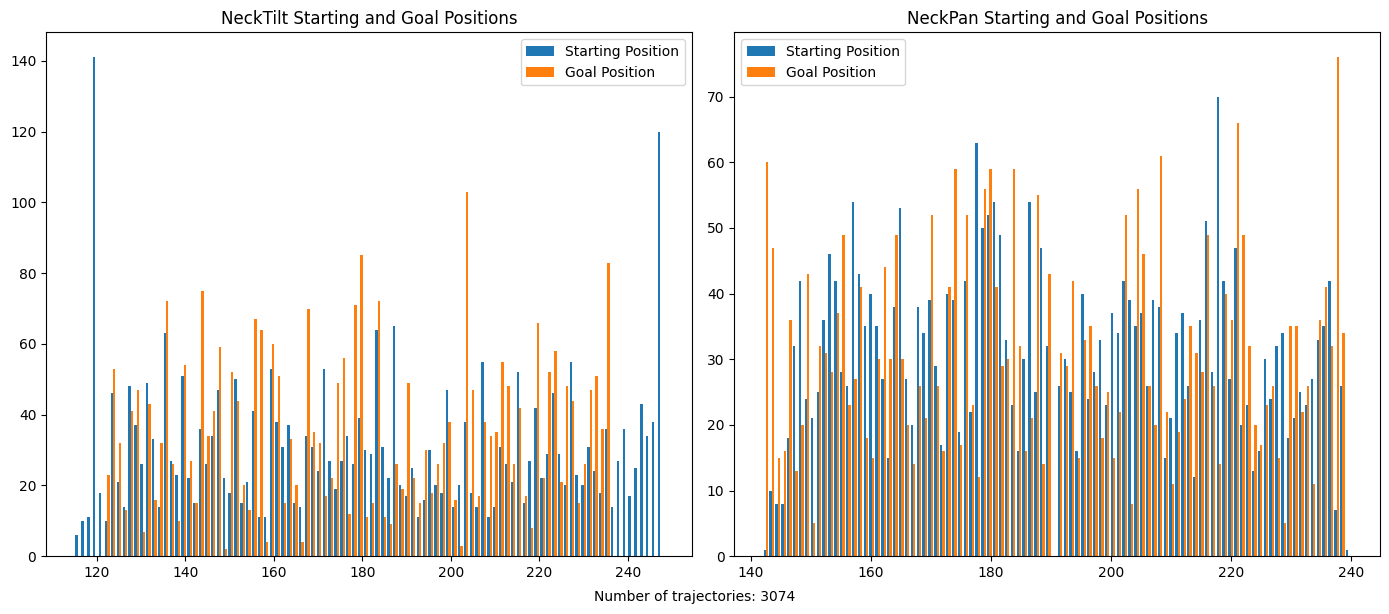

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot for NeckTilt
starting_positions_tilt = [mapping_metrics[key]['StartingPosition'][servoIndices['NeckTilt']] for key in mapping_metrics]
goal_positions_tilt = [mapping_metrics[key]['GoalPosition'][servoIndices['NeckTilt']] for key in mapping_metrics]
axs[0].hist([starting_positions_tilt, goal_positions_tilt], bins=100, label=['Starting Position', 'Goal Position'])
axs[0].set_title('NeckTilt Starting and Goal Positions')
axs[0].legend()

# Plot for NeckPan
starting_positions_pan = [mapping_metrics[key]['StartingPosition'][servoIndices['NeckPan']] for key in mapping_metrics]
goal_positions_pan = [mapping_metrics[key]['GoalPosition'][servoIndices['NeckPan']] for key in mapping_metrics]
axs[1].hist([starting_positions_pan, goal_positions_pan], bins=100, label=['Starting Position', 'Goal Position'])
axs[1].set_title('NeckPan Starting and Goal Positions')
axs[1].legend()

#Text with the number of trajectories
fig.text(0.5, -0.01, f'Number of trajectories: {len(all_trajectories)}', ha='center')

plt.tight_layout()
plt.show()

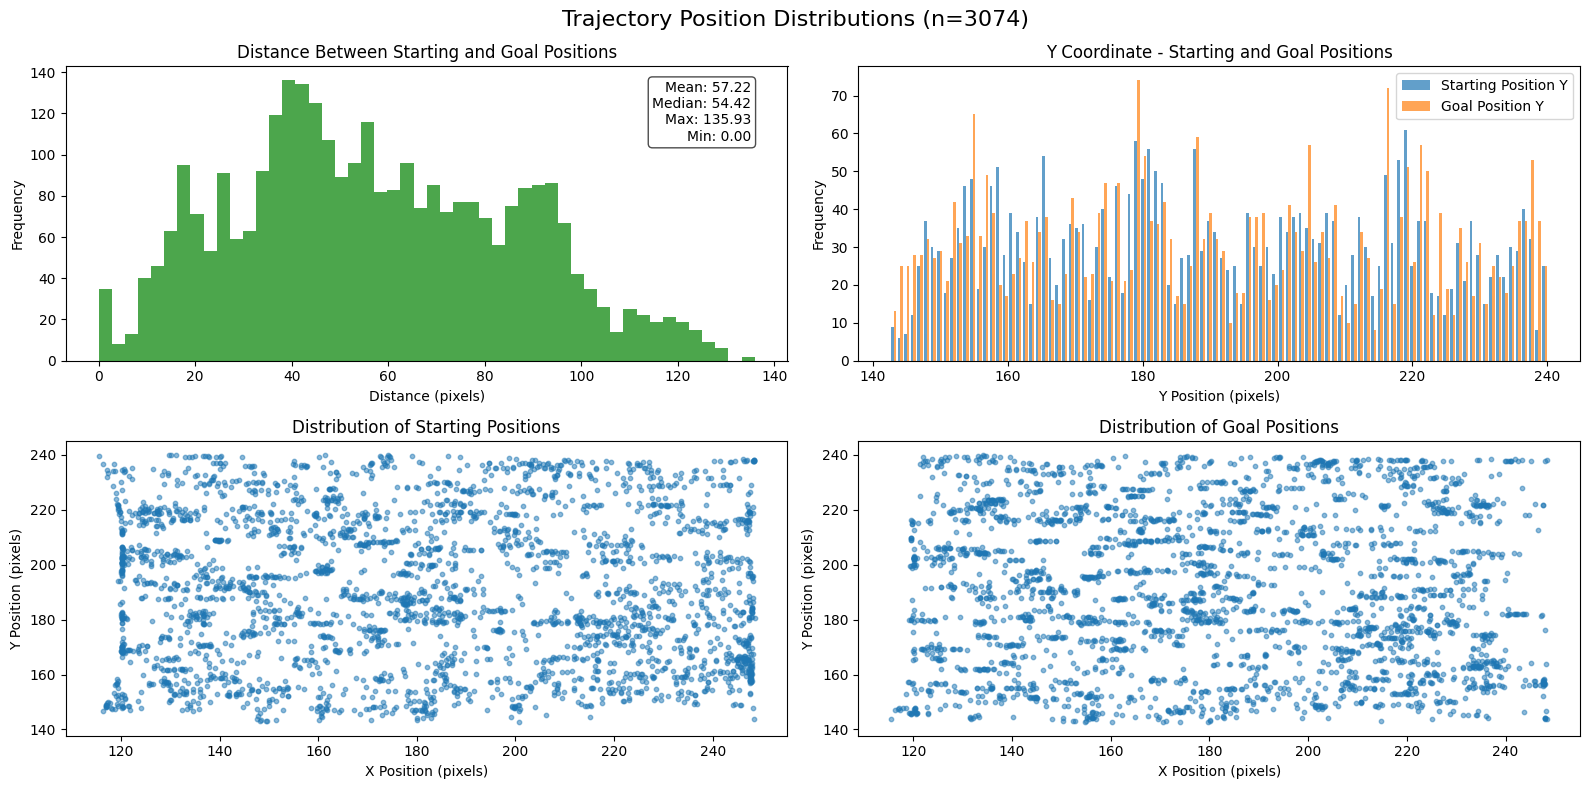

In [9]:
# Plot distribution of starting and goal positions from trajectory data
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

# Extract starting and ending positions from trajectories
traj_start_positions_x = [all_trajectories[key][0][0] for key in all_trajectories.keys()]
traj_start_positions_y = [all_trajectories[key][0][1] for key in all_trajectories.keys()]
traj_goal_positions_x = [all_trajectories[key][-1][0] for key in all_trajectories.keys()]
traj_goal_positions_y = [all_trajectories[key][-1][1] for key in all_trajectories.keys()]

# Plot X positions
axs[0, 0].hist([traj_start_positions_x, traj_goal_positions_x], bins=100, 
               label=['Starting Position X', 'Goal Position X'], alpha=0.7)
axs[0, 0].set_title('X Coordinate - Starting and Goal Positions')
axs[0, 0].set_xlabel('X Position (pixels)')
axs[0, 0].set_ylabel('Frequency')
axs[0, 0].legend()
# Calculate the distance between start and goal positions
distances = []
for key in all_trajectories.keys():
    start = np.array(all_trajectories[key][0])
    goal = np.array(all_trajectories[key][-1])
    distance = np.linalg.norm(goal - start)
    distances.append(distance)

# Plot distance distribution
axs[0, 0].clear()  # Clear the previous histogram
axs[0, 0].hist(distances, bins=50, color='green', alpha=0.7)
axs[0, 0].set_title('Distance Between Starting and Goal Positions')
axs[0, 0].set_xlabel('Distance (pixels)')
axs[0, 0].set_ylabel('Frequency')

# Add text with statistics
mean_distance = np.mean(distances)
median_distance = np.median(distances)
max_distance = np.max(distances)
min_distance = np.min(distances)
stats_text = f"Mean: {mean_distance:.2f}\nMedian: {median_distance:.2f}\nMax: {max_distance:.2f}\nMin: {min_distance:.2f}"
axs[0, 0].text(0.95, 0.95, stats_text, transform=axs[0, 0].transAxes, 
              verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Plot Y positions
axs[0, 1].hist([traj_start_positions_y, traj_goal_positions_y], bins=100, 
               label=['Starting Position Y', 'Goal Position Y'], alpha=0.7)
axs[0, 1].set_title('Y Coordinate - Starting and Goal Positions')
axs[0, 1].set_xlabel('Y Position (pixels)')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].legend()

# Scatter plot of starting positions
axs[1, 0].scatter(traj_start_positions_x, traj_start_positions_y, alpha=0.5, s=10)
axs[1, 0].set_title('Distribution of Starting Positions')
axs[1, 0].set_xlabel('X Position (pixels)')
axs[1, 0].set_ylabel('Y Position (pixels)')

# Scatter plot of goal positions
axs[1, 1].scatter(traj_goal_positions_x, traj_goal_positions_y, alpha=0.5, s=10)
axs[1, 1].set_title('Distribution of Goal Positions')
axs[1, 1].set_xlabel('X Position (pixels)')
axs[1, 1].set_ylabel('Y Position (pixels)')

# Add text with number of trajectories
fig.suptitle(f'Trajectory Position Distributions (n={len(all_trajectories)})', fontsize=16)

plt.tight_layout()
plt.show()


## Start Current plots

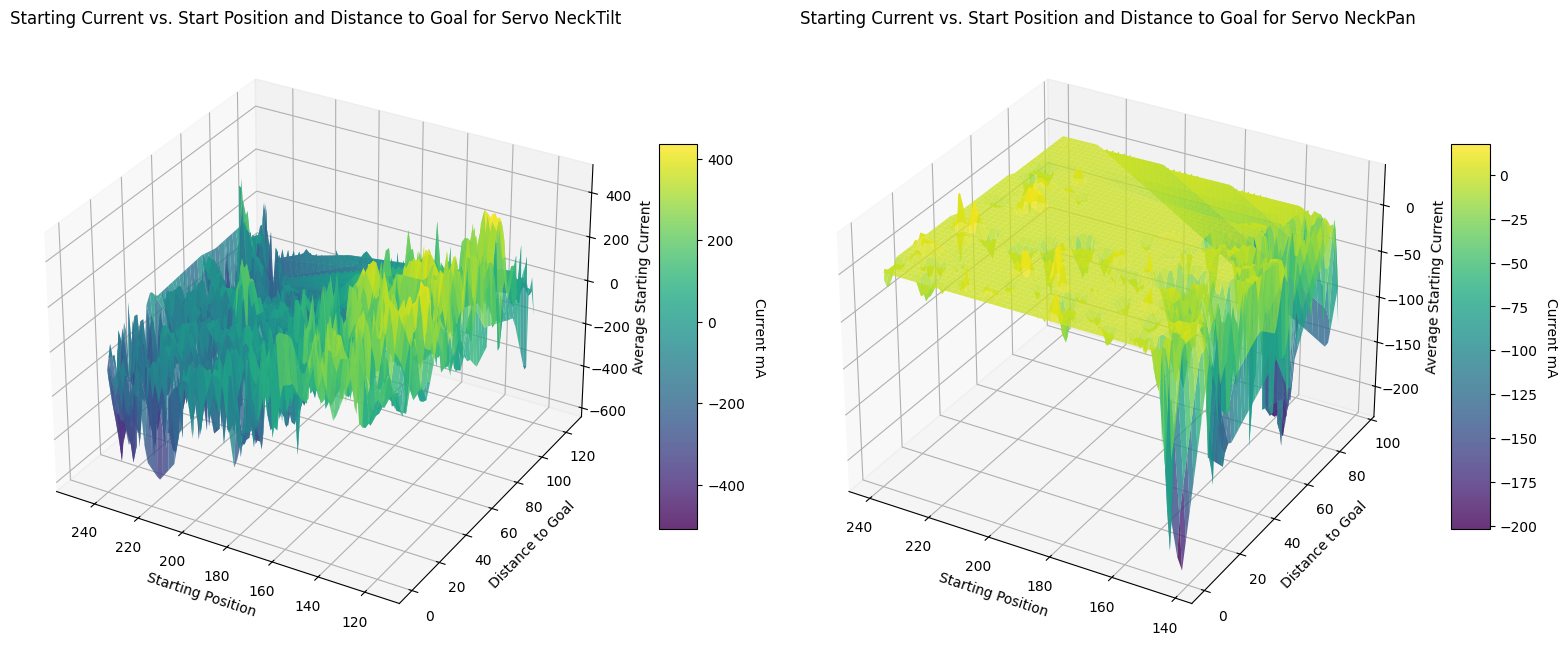

In [10]:
plot_start_current_vs_distance(mapping_metrics, ['NeckTilt', 'NeckPan'], servoIndices, mapping_metrics.keys())

# Torque current plots

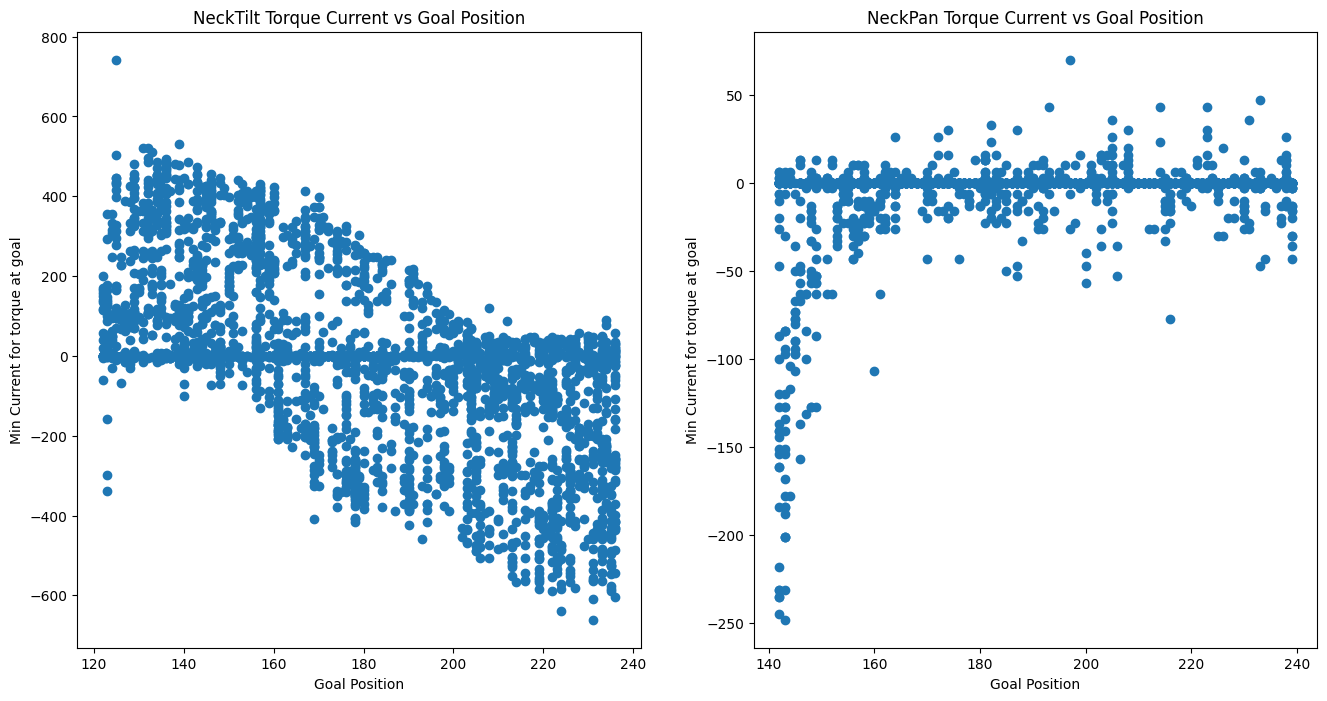

In [11]:
#plot MinCurrentForTorqueAtGoal vs goal position
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
for i,servo in enumerate(servos_in_use):
    goal_positions = [mapping_metrics[key]['GoalPosition'][servoIndices[servo]] for key in mapping_metrics]
    min_currents = [mapping_metrics[key]['MinCurrentForTorqueAtGoal'][servoIndices[servo]] for key in mapping_metrics]
    axs[i].scatter(goal_positions, min_currents)
    axs[i].set_title(f'{servo} Torque Current vs Goal Position')
    axs[i].set_xlabel('Goal Position')
    axs[i].set_ylabel('Min Current for torque at goal')

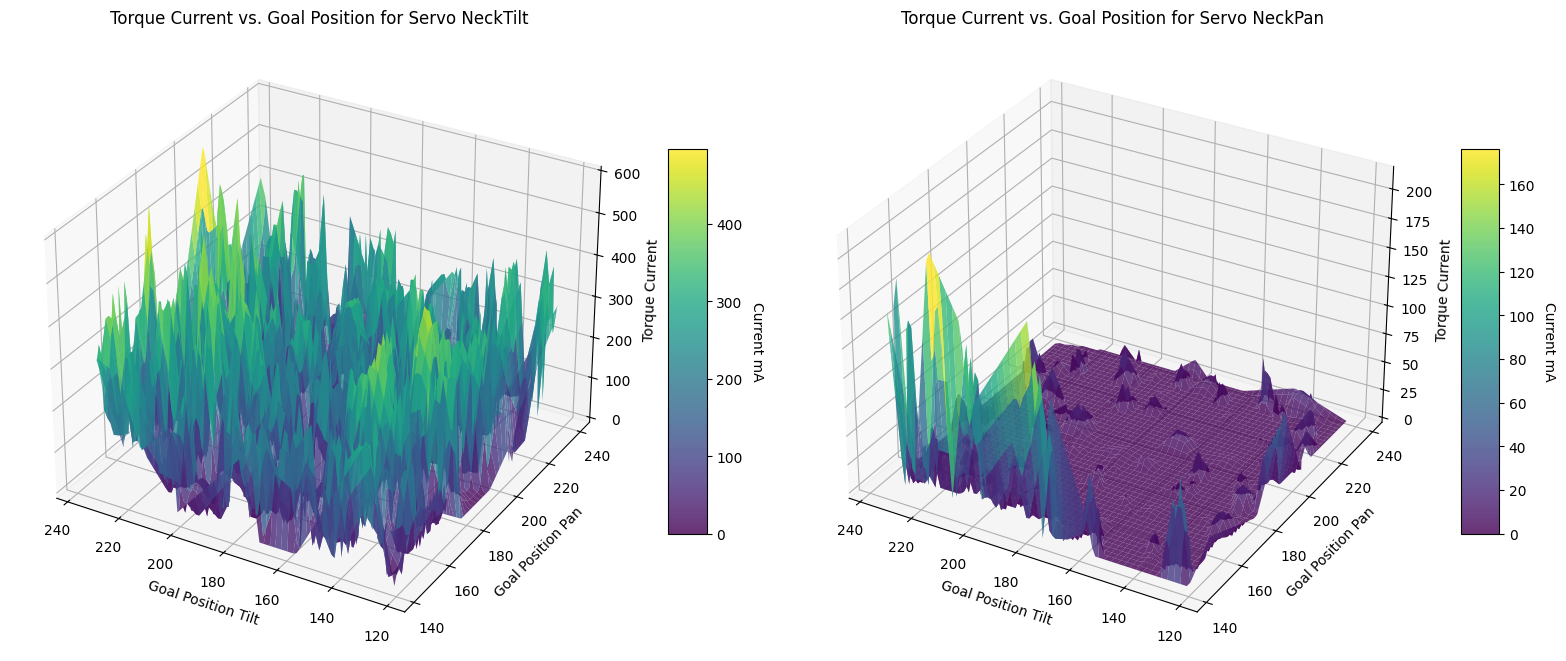

In [12]:
plot_torque_current_vs_positions(mapping_metrics, ['NeckTilt', 'NeckPan'], servoIndices, mapping_metrics.keys())

# Average current plots

Max average current for NeckTilt: 1034.88
Max average current for NeckPan: 305.76


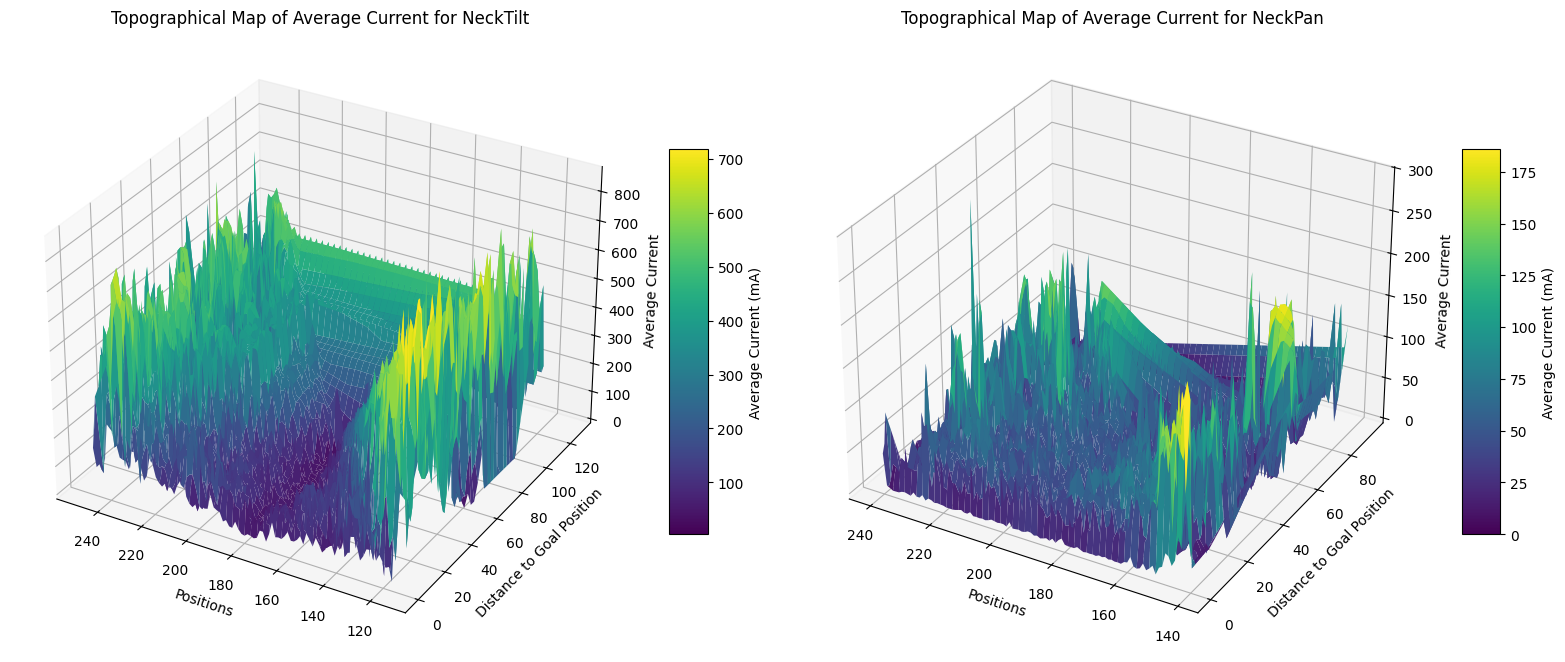

In [13]:
plot_average_current(all_currents, all_trajectories, ['NeckTilt', 'NeckPan'])

In [14]:
#max value of current of all the keys current for each servo
max_currents = {servo: max([np.max(all_currents[key][:, servoIndices[servo]]) for key in all_currents.keys()]) for servo in servos_in_use}
print(f"Max currents: {max_currents}")

max_x_angles = {servo: max([np.max(all_angles[key][:, 0]) for key in all_angles.keys()]) for servo in servos_in_use}
max_y_angles = {servo: max([np.max(all_angles[key][:, 1]) for key in all_angles.keys()]) for servo in servos_in_use}
max_z_angles = {servo: max([np.max(all_angles[key][:, 2]) for key in all_angles.keys()]) for servo in servos_in_use}
print(f"Max X angles: {max_x_angles}")
print(f"Max Y angles: {max_y_angles}")
print(f"Max Z angles: {max_z_angles}")

max_positions = {servo: max([np.max(all_trajectories[key][:, servoIndices[servo]]) for key in all_trajectories.keys()]) for servo in servos_in_use}
min_positions = {servo: min([np.min(all_trajectories[key][:, servoIndices[servo]]) for key in all_trajectories.keys()]) for servo in servos_in_use}
print(f"Max positions: {max_positions}")
print(f"Min positions: {min_positions}")


Max currents: {'NeckTilt': np.float64(1236.48), 'NeckPan': np.float64(598.08)}
Max X angles: {'NeckTilt': np.float64(73.28), 'NeckPan': np.float64(73.28)}
Max Y angles: {'NeckTilt': np.float64(73.88), 'NeckPan': np.float64(73.88)}
Max Z angles: {'NeckTilt': np.float64(359.79), 'NeckPan': np.float64(359.79)}
Max positions: {'NeckTilt': np.float64(249.32), 'NeckPan': np.float64(240.53)}
Min positions: {'NeckTilt': np.float64(115.43), 'NeckPan': np.float64(141.63)}


## Normalised data

In [15]:
normlised_currents = normalise_data(all_currents, servos_in_use)
normlised_trajectories = normalise_data(all_trajectories, servos_in_use)
normlised_gyro = normalise_data(all_gyro, servos_in_use)
normlised_accel = normalise_data(all_accel, servos_in_use)
normlised_angles = normalise_data(all_angles, servos_in_use)

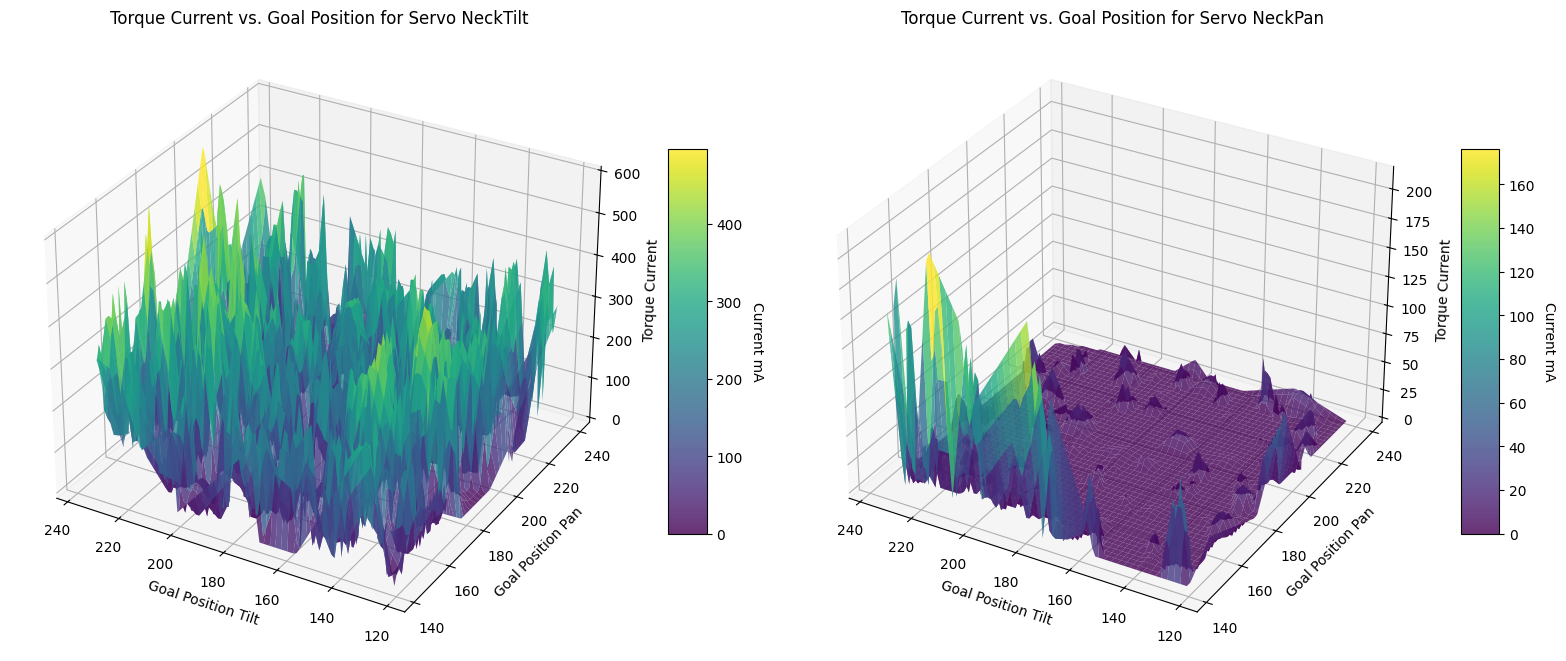

In [16]:
plot_torque_current_vs_positions(mapping_metrics, ['NeckTilt', 'NeckPan'], servoIndices, mapping_metrics.keys())

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import mpl_toolkits.mplot3d.axes3d as p3
from matplotlib.animation import PillowWriter
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import os

def plot_head_trajectory(trajectory, traj_id, output_file='plots/head_trajectory.gif', 
                        neutral_tilt=183, neutral_pan=192, head_model_path=None):
    """
    Plot head trajectory in 3D space and save as GIF.
    
    Args:
        trajectory: List of [tilt, pan] coordinates
        traj_id: Unique ID of the trajectory
        output_file: Output GIF filename
        neutral_tilt: Neutral position for tilt (default 183)
        neutral_pan: Neutral position for pan (default 192)
        head_model_path: Path to head model file (optional)
    """
    # Convert trajectory to numpy array
    traj = np.array(trajectory)
    
    # Transform coordinates relative to neutral position
    tilt = traj[:, 0] - neutral_tilt  # Forward/backward
    pan = traj[:, 1] - neutral_pan    # Left/right
    
    # Setup the figure and 3D axes
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    fig.suptitle(f"Trajectory: {traj_id}")
    
    # Load head model if provided
    head_model = None
    if head_model_path and os.path.exists(head_model_path):
        try:
            # Check if it's a .glb file
            if head_model_path.endswith('.glb'):
                try:
                    import trimesh
                    head_model = trimesh.load(head_model_path)
                    print(f"Loaded GLB model: {head_model_path}")
                except ImportError:
                    print("trimesh package not found. Install with: pip install trimesh")
                    head_model = None
                except Exception as e:
                    print(f"Error loading GLB file: {e}")
                    head_model = None
        except Exception as e:
            print(f"Error loading model file: {e}")
            head_model = None
    
    def update(frame):
        ax.cla()  # Clear the current axis
        
        # Plot trajectory up to current frame
        ax.plot3D(pan[:frame+1], tilt[:frame+1], np.zeros(frame+1), 
                 'b-', linewidth=2, label='Head Path')
        
        # Plot current position
        if frame > 0:
            ax.scatter(pan[frame], tilt[frame], 0, 
                      color='red', s=100, label='Current Position')
        
        # Plot neutral position as a vertical line
        ax.plot([0, 0], [0, 0], [0, 0], 
                'k--', linewidth=1, label='Centered position')
        
        # Plot head model at current position if available
        if head_model is not None and 'trimesh' in sys.modules:
            # For GLB files using trimesh
            try:
                # Scale and position the head model
                scale = 0.1  # Adjust scale as needed
                x_offset = pan[frame] if frame > 0 else 0
                y_offset = tilt[frame] if frame > 0 else 0
                
                # Extract mesh data from the model
                for mesh_name, mesh in head_model.geometry.items():
                    vertices = mesh.vertices.copy() * scale
                    vertices[:, 0] += x_offset
                    vertices[:, 1] += y_offset
                    
                    # Get faces for triangulation
                    faces = mesh.faces
                    
                    # Create triangles for plotting
                    triangles = vertices[faces]
                    
                    # Plot the mesh
                    collection = Poly3DCollection(triangles, alpha=0.4)
                    collection.set_facecolor('cyan')
                    ax.add_collection3d(collection)
            except Exception as e:
                print(f"Error rendering GLB model: {e}")
        
        # Set labels
        ax.set_xlabel('Pan (Left/Right)', fontsize=10)
        ax.set_ylabel('Tilt (Forward/Backward)', fontsize=10)
        ax.set_zlabel('', fontsize=10)
        ax.set_title('Head Movement Trajectory', fontsize=12)
        
        # Add legend
        ax.legend()
        
        # Set consistent axis limits centered around neutral position
        max_range = max(max(abs(pan)), max(abs(tilt))) + 5
        ax.set_xlim([-max_range, max_range])
        ax.set_ylim([-max_range, max_range])
        ax.set_zlim([-1, 1])
        
        # Add grid
        ax.grid(True)
        
        # Add text annotations for directions
        ax.text(max_range, 0, 0, 'Right', fontsize=8)
        ax.text(-max_range, 0, 0, 'Left', fontsize=8)
        ax.text(0, max_range, 0, 'Forward', fontsize=8)
        ax.text(0, -max_range, 0, 'Backward', fontsize=8)
        
        
    
    # Create animation
    frames = len(trajectory)
    anim = FuncAnimation(fig, update, frames=frames, 
                        interval=100, blit=False)
    
    # Save as GIF
    writer = PillowWriter(fps=15)
    anim.save(output_file, writer=writer)
    plt.close()

# Pick a random unique id
unique_ids = np.array(list(all_trajectories.keys()))

random_id = np.random.choice(unique_ids)

random_id = 35271
plot_head_trajectory(
    all_trajectories[random_id], 
    traj_id=random_id, 
    output_file=f"plots/Trajectory_{random_id}.gif"
)
print(random_id)

35271


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import mpl_toolkits.mplot3d.axes3d as p3
from matplotlib.animation import PillowWriter
from mpl_toolkits.mplot3d import Axes3D
import os

def plot_head_rotation_trajectory(trajectory, traj_id, output_file='plots/head_rotation_gaze.gif',
                                 neutral_tilt=183, neutral_pan=192, head_length=10,
                                 box_size=1.0, gaze_length_factor=0.75):
    """
    Plot head rotation trajectory in 3D space, visualizing orientation
    with a box marker and a gaze line originating from the box. Saves as GIF.

    Args:
        trajectory: List of [tilt, pan] coordinates in degrees.
        traj_id: Unique ID of the trajectory.
        output_file: Output GIF filename.
        neutral_tilt: Neutral position for tilt servo (degrees), head looks straight.
        neutral_pan: Neutral position for pan servo (degrees), head looks straight.
        head_length: Distance from origin to box center (visual scale).
        box_size: Half-side length of the cube marker.
        gaze_length_factor: Multiplier for head_length to determine gaze line length.
    """
    # Convert trajectory to numpy array
    traj_deg = np.array(trajectory)

    if traj_deg.ndim != 2 or traj_deg.shape[1] != 2:
        print(f"Error: Trajectory for ID {traj_id} has unexpected shape: {traj_deg.shape}. Skipping.")
        return
    if traj_deg.shape[0] == 0:
        print(f"Warning: Trajectory for ID {traj_id} is empty. Skipping.")
        return

    # Apply neutral offset: Calculate rotation relative to the centered position
    tilt_deg = traj_deg[:, 0] - neutral_tilt
    pan_deg = traj_deg[:, 1] - neutral_pan

    # Convert degrees to radians
    tilt_rad = np.radians(tilt_deg)
    pan_rad = np.radians(pan_deg)

    # Calculate 3D coordinates of the box center using spherical mapping
    # Assumes: +X Forward, +Y Left, +Z Up
    # Centered gaze along +X (tilt=0, pan=0 -> (L,0,0))
    x = head_length * np.cos(tilt_rad) * np.cos(pan_rad)
    y = head_length * np.cos(tilt_rad) * np.sin(pan_rad) # Positive pan moves towards +Y (Left)
    z = head_length * np.sin(tilt_rad)                 # Positive tilt moves towards +Z (Up)

    # Setup the figure and 3D axes
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    fig.suptitle(f"Head Rotation Trajectory: {traj_id}")

    # Pre-calculate axis limits to include gaze line
    limit = (head_length * (1 + gaze_length_factor) + box_size) * 1.1 # Padding includes gaze
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    ax.set_box_aspect([1,1,1]) # Ensure equal aspect ratio

    # Define cube edges relative to its center (0,0,0)
    s = box_size # half-side length
    points = np.array([[-s,-s,-s], [ s,-s,-s], [ s, s,-s], [-s, s,-s],
                       [-s,-s, s], [ s,-s, s], [ s, s, s], [-s, s, s]])
    edges = [[0, 1], [1, 2], [2, 3], [3, 0],  # bottom face
             [4, 5], [5, 6], [6, 7], [7, 4],  # top face
             [0, 4], [1, 5], [2, 6], [3, 7]]  # vertical edges

    def update(frame):
        ax.cla()  # Clear the current axis

        # Plot trajectory path up to current frame (path of the box center)
        ax.plot3D(x[:frame+1], y[:frame+1], z[:frame+1],
                 'b-', linewidth=1.5, label='Head Center Path') # Slightly thinner path line

        # Current box center position
        center_pos = np.array([x[frame], y[frame], z[frame]])

        # --- Draw Box ---
        cube_points = points + center_pos # Translate cube corners
        for edge in edges:
            line = np.array([cube_points[edge[0]], cube_points[edge[1]]])
            ax.plot3D(line[:,0], line[:,1], line[:,2], color="darkred", linewidth=1) # Darker red box
        ax.scatter(center_pos[0], center_pos[1], center_pos[2], marker='s', s=0, label='Head Position (Box)') # Invisible point for legend

        # --- Calculate and Draw Gaze Line ---
        # The direction vector is simply the normalized position vector (origin to center)
        current_head_length = np.linalg.norm(center_pos)
        if current_head_length > 1e-6: # Avoid division by zero
            direction = center_pos / current_head_length
            # Calculate the end point of the gaze line
            gaze_visual_length = head_length * gaze_length_factor # Length of the visible ray
            gaze_end_point = center_pos + direction * gaze_visual_length
        else:
            # If head is exactly at origin, point gaze forward (+X) for safety
            direction = np.array([1.0, 0.0, 0.0])
            gaze_visual_length = head_length * gaze_length_factor
            gaze_end_point = center_pos + direction * gaze_visual_length

        # Plot the gaze line originating from the box center
        ax.plot3D([center_pos[0], gaze_end_point[0]],
                  [center_pos[1], gaze_end_point[1]],
                  [center_pos[2], gaze_end_point[2]],
                  '#FF8C00', # Dark Orange color
                  linewidth=2.0, linestyle='-', label='Gaze Direction Ray')

        # Plot centered position marker at the origin (0,0,0)
        ax.scatter(0, 0, 0, color='black', marker='o', s=50, label='Centered Position (Origin)')
        # Optionally plot neutral gaze direction (+X axis)
        ax.plot3D([0, head_length], [0, 0], [0,0], 'k:', linewidth=0.8, label='Neutral Gaze (+X)')

        # Set labels
        ax.set_xlabel('X (Forward / Backward)', fontsize=10)
        ax.set_ylabel('Y (Left / Right)', fontsize=10)
        ax.set_zlabel('Z (Up / Down)', fontsize=10)
        ax.set_title(f'Frame {frame+1}/{len(x)} | Tilt: {tilt_deg[frame]:.1f}°, Pan: {pan_deg[frame]:.1f}°', fontsize=12)

        # Set consistent axis limits and aspect ratio
        ax.set_xlim([-limit, limit])
        ax.set_ylim([-limit, limit])
        ax.set_zlim([-limit, limit])
        ax.set_box_aspect([1,1,1]) # Re-apply after cla()

        # Add legend
        ax.legend(loc='upper left', fontsize=8)

        # Add grid
        ax.grid(True)

        # Fixed view angle set outside the loop

    # Set a fixed view angle outside the loop
    ax.view_init(elev=25, azim=-60)

    # Create animation
    frames = len(x)
    anim = FuncAnimation(fig, update, frames=frames,
                        interval=50, blit=False)

    # Ensure the output directory exists
    output_dir = os.path.dirname(output_file)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")

    # Save as GIF
    try:
        writer = PillowWriter(fps=20)
        anim.save(output_file, writer=writer)
        print(f"Rotation animation (gaze ray) saved to {output_file}")
    except Exception as e:
        print(f"Error saving rotation animation: {e}")
        print("Ensure you have Pillow installed: pip install Pillow")

    plt.close(fig)

# --- Example Usage ---
# Ensure 'all_trajectories' dictionary exists and contains your data

# Example:
if 'all_trajectories' in locals() and all_trajectories:
    unique_ids = np.array(list(all_trajectories.keys()))
    if len(unique_ids) > 0:
        random_id = np.random.choice(unique_ids)
        

        print(f"Plotting rotation trajectory (box) for ID: {random_id}")

        plot_head_rotation_trajectory(
            trajectory=all_trajectories[random_id],
            traj_id=random_id,
            output_file=f"plots/Rotation_Trajectory_Box_{random_id}.gif",
            neutral_tilt=183,
            neutral_pan=192,
            head_length=10,
            box_size=1.5 # Adjust size of the box marker
        )
    else:
        print("Trajectories dictionary is empty.")
else:
    print("Trajectories data ('all_trajectories') not found. Please load data first.")

Plotting rotation trajectory (box) for ID: 711267
Rotation animation (gaze ray) saved to plots/Rotation_Trajectory_Box_711267.gif


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import mpl_toolkits.mplot3d.axes3d as p3
from matplotlib.animation import PillowWriter
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import os

# --- Helper Rotation Matrices ---
def rotation_matrix_x(angle_rad):
    """Rotation matrix around X-axis."""
    c, s = np.cos(angle_rad), np.sin(angle_rad)
    return np.array([[1, 0, 0],
                     [0, c, -s],
                     [0, s, c]])

def rotation_matrix_z(angle_rad):
    """Rotation matrix around Z-axis."""
    c, s = np.cos(angle_rad), np.sin(angle_rad)
    return np.array([[c, -s, 0],
                     [s, c, 0],
                     [0, 0, 1]])
# --------------------------------

def plot_head_rotation_trajectory(trajectory, traj_id, output_file='plots/head_physical_rotation.gif',
                                 neutral_tilt=183, neutral_pan=192,
                                 rotation_center_world=np.array([0.0, 0.0, 25.0]),
                                 head_length=15.0, box_size=1.5, gaze_length_factor=1.0):
    """
    Plot head rotation trajectory based on physical model.

    Args:
        trajectory: List of [tilt, pan] coordinates in degrees.
        traj_id: Unique ID of the trajectory.
        output_file: Output GIF filename.
        neutral_tilt: Neutral position for tilt servo (degrees), head looks straight (+Y).
        neutral_pan: Neutral position for pan servo (degrees), head looks straight (+Y).
        rotation_center_world: Coordinates (cm) of the Pan/Tilt intersection point
                                in the world frame (default [0, 0, 25]).
        head_length: Distance (cm) from rotation center to visualized head point
                     along the neutral forward direction (+Y).
        box_size: Half-side length (cm) of the cube marker.
        gaze_length_factor: Multiplier for head_length to determine gaze line visual length.
    """
    # Convert trajectory to numpy array
    traj_deg = np.array(trajectory)

    if traj_deg.ndim != 2 or traj_deg.shape[1] != 2:
        print(f"Error: Trajectory for ID {traj_id} has unexpected shape: {traj_deg.shape}. Skipping.")
        return
    if traj_deg.shape[0] == 0:
        print(f"Warning: Trajectory for ID {traj_id} is empty. Skipping.")
        return

    # Apply neutral offset: Calculate rotation relative to the centered position
    # Note: Sign might need adjustment depending on motor direction vs. coordinate system
    tilt_deg = traj_deg[:, 0] - neutral_tilt
    pan_deg = traj_deg[:, 1] - neutral_pan

    # Convert degrees to radians
    # Positive Tilt = Up (+Z). Positive Pan = Left (+X).
    # Adjust signs if motor definition differs. E.g., np.radians(-(pan_deg)) if needed.
    tilt_rad = np.radians(tilt_deg)
    pan_rad = np.radians(-pan_deg)

    tilt_center = np.radians(183)
    pan_center = np.radians(-192)
    #rotation_center_world = np.array([tilt_center, pan_center, 25.0])
    # Define vectors relative to the rotation center in the *neutral* head pose
    neutral_head_point_local = np.array([0.0, head_length, 0.0]) # Point 'head_length' cm forward (+Y)
    neutral_gaze_dir_local = np.array([0.0, 1.0, 0.0])           # Unit vector pointing forward (+Y)

    # Calculate world positions and gaze directions for the whole trajectory
    head_pos_world = np.zeros((len(trajectory), 3))
    gaze_dir_world = np.zeros((len(trajectory), 3))
    R_combined_list = []  # Store rotation matrices for each frame

    for i in range(len(trajectory)):
        # Combined rotation matrix (Pan around Z first, then Tilt around new X)
        R_pan = rotation_matrix_z(pan_rad[i])
        R_tilt = rotation_matrix_x(tilt_rad[i])
        R_combined = R_pan @ R_tilt # Applies Tilt (local X) then Pan (world Z)
        R_combined_list.append(R_combined)

        # Rotate the local point and direction vector to get their world orientation (relative to rotation center)
        current_head_point_rotated = R_combined @ neutral_head_point_local
        current_gaze_dir_rotated = R_combined @ neutral_gaze_dir_local

        # Calculate the absolute world position of the head point (box center)
        head_pos_world[i] = rotation_center_world + current_head_point_rotated
        gaze_dir_world[i] = current_gaze_dir_rotated # Already a unit vector

    x_traj, y_traj, z_traj = head_pos_world[:, 0], head_pos_world[:, 1], head_pos_world[:, 2]

    # Setup the figure and 3D axes
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    fig.suptitle(f"Head Rotation Trajectory (Physical Model): {traj_id}")

    # Determine axis limits centered around the rotation center
    gaze_ends = head_pos_world + gaze_dir_world * (head_length * gaze_length_factor)
    # Consider trajectory points, gaze end points, and the box extent around the trajectory
    all_points_to_consider = np.vstack((
        head_pos_world + box_size,
        head_pos_world - box_size,
        gaze_ends,
        rotation_center_world.reshape(1, 3)
    ))
    deviations = np.abs(all_points_to_consider - rotation_center_world)
    max_range = np.max(deviations) * 1.1 # Find the single largest deviation and add padding

    # Set symmetric limits around the rotation center
    lim_x = (rotation_center_world[0] - max_range, rotation_center_world[0] + max_range)
    lim_y = (rotation_center_world[1] - max_range, rotation_center_world[1] + max_range)
    lim_z = (rotation_center_world[2] - max_range, rotation_center_world[2] + max_range)

    # Define cube edges relative to its center (0,0,0)
    s = box_size # half-side length
    points = np.array([[-s,-s,-s], [ s,-s,-s], [ s, s,-s], [-s, s,-s],
                       [-s,-s, s], [ s,-s, s], [ s, s, s], [-s, s, s]])
    edges = [[0, 1], [1, 2], [2, 3], [3, 0],  # bottom face
             [4, 5], [5, 6], [6, 7], [7, 4],  # top face
             [0, 4], [1, 5], [2, 6], [3, 7]]  # vertical edges

    # Define eye positions on back face (relative to box center)
    eye_radius = s * 0.25  # Eye size relative to box size
    eye_spacing = s * 0.5  # Distance between eyes
    left_eye_pos = np.array([-eye_spacing/2, 1.4*s, 0])  # Left eye on front    face (+y)
    right_eye_pos = np.array([eye_spacing/2, 1.4*s, 0])  # Right eye on front face (+y)

    # Define ear cylinders (relative to box center) - horizontal orientation
    ear_radius = s * 0.3
    ear_height = s * 0.5  # Reduced height for shorter ears
    left_ear_pos = np.array([1.5*-s, 0, 0])  # Left ear position at the side
    right_ear_pos = np.array([1.5*s, 0, 0])  # Right ear position at the side

    def update(frame):
        ax.cla()  # Clear the current axis

        # Plot trajectory path up to current frame
        ax.plot3D(x_traj[:frame+1], y_traj[:frame+1], z_traj[:frame+1],
                 'b-', linewidth=1.5, label='Head Center Path')

        # Current head position and gaze direction
        current_center_pos = head_pos_world[frame]
        current_gaze_dir = gaze_dir_world[frame]

        # --- Draw Box ---
        # Rotate the box to align with the gaze direction
        # Get the rotation matrix for the current frame
        current_R_combined = R_combined_list[frame]
        # First rotate the points using the combined rotation matrix
        rotated_points = np.array([current_R_combined @ p for p in points])
        # Then translate to the current head position
        cube_points = rotated_points + current_center_pos

        # Define the faces of the cube for solid rendering
        faces = [
            [0, 1, 2, 3],  # bottom face (-z)
            [4, 5, 6, 7],  # top face (+z)
            [0, 1, 5, 4],  # front face (-y) -> Now without eyes
            [2, 3, 7, 6],  # back face (+y) -> Now with eyes
            [0, 3, 7, 4],  # left face (-x)
            [1, 2, 6, 5]   # right face (+x)
        ]

        # Plot each face as a filled polygon (white box)
        for face in faces:
            x = [cube_points[i][0] for i in face]
            y = [cube_points[i][1] for i in face]
            z = [cube_points[i][2] for i in face]
            # Add the first point again to close the polygon
            x.append(x[0])
            y.append(y[0])
            z.append(z[0])
            ax.plot3D(x, y, z, color="black", linewidth=1)
            # Create a polygon and fill it
            verts = [list(zip(x, y, z))]
            ax.add_collection3d(Poly3DCollection(verts, facecolors='white', alpha=1, linewidths=1, edgecolors='black'))

        # Add invisible marker for legend
        ax.scatter(current_center_pos[0], current_center_pos[1], current_center_pos[2],
                   marker='s', s=0, label='Robot Head') # Invisible for legend

        # --- Draw Eyes on Back Face ---
        # Rotate and translate eye positions
        left_eye_world = current_R_combined @ left_eye_pos + current_center_pos
        right_eye_world = current_R_combined @ right_eye_pos + current_center_pos

        # Draw eyes as circles
        u = np.linspace(0, 2 * np.pi, 20)
        v = np.linspace(0, np.pi, 10)

        # Left eye
        x = left_eye_world[0] + eye_radius * np.outer(np.cos(u), np.sin(v))
        y = left_eye_world[1] + eye_radius * np.outer(np.sin(u), np.sin(v))
        z = left_eye_world[2] + eye_radius * np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_surface(x, y, z, color='blue', alpha=0.8)

        # Right eye
        x = right_eye_world[0] + eye_radius * np.outer(np.cos(u), np.sin(v))
        y = right_eye_world[1] + eye_radius * np.outer(np.sin(u), np.sin(v))
        z = right_eye_world[2] + eye_radius * np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_surface(x, y, z, color='blue', alpha=0.8)

        # --- Draw Ears (Horizontal Cylinders) ---
        # Rotate and translate ear positions
        left_ear_world = current_R_combined @ left_ear_pos + current_center_pos
        right_ear_world = current_R_combined @ right_ear_pos + current_center_pos

        # Create horizontal cylinders (along x-axis)
        theta = np.linspace(0, 2 * np.pi, 20)
        x_cyl = np.linspace(-ear_height/2, ear_height/2, 10)  # x-axis for horizontal orientation
        theta_grid, x_grid = np.meshgrid(theta, x_cyl)

        # Calculate cylinder points for horizontal orientation
        y_cyl = ear_radius * np.cos(theta_grid)
        z_cyl = ear_radius * np.sin(theta_grid)

        # Rotate cylinder points for left ear
        left_ear_cylinder_x = np.zeros_like(x_grid)
        left_ear_cylinder_y = np.zeros_like(y_cyl)
        left_ear_cylinder_z = np.zeros_like(z_cyl)

        for i in range(len(x_cyl)):
            for j in range(len(theta)):
                # Left ear - horizontal along x-axis
                point = np.array([x_grid[i,j], y_cyl[i,j], z_cyl[i,j]])
                rotated_point = current_R_combined @ point
                left_ear_cylinder_x[i,j] = rotated_point[0] + left_ear_world[0]
                left_ear_cylinder_y[i,j] = rotated_point[1] + left_ear_world[1]
                left_ear_cylinder_z[i,j] = rotated_point[2] + left_ear_world[2]

        # Plot left ear
        ax.plot_surface(left_ear_cylinder_x, left_ear_cylinder_y, left_ear_cylinder_z, color='black', alpha=0.8)

        # Rotate cylinder points for right ear
        right_ear_cylinder_x = np.zeros_like(x_grid)
        right_ear_cylinder_y = np.zeros_like(y_cyl)
        right_ear_cylinder_z = np.zeros_like(z_cyl)

        for i in range(len(x_cyl)):
            for j in range(len(theta)):
                # Right ear - horizontal along x-axis
                point = np.array([x_grid[i,j], y_cyl[i,j], z_cyl[i,j]])
                rotated_point = current_R_combined @ point
                right_ear_cylinder_x[i,j] = rotated_point[0] + right_ear_world[0]
                right_ear_cylinder_y[i,j] = rotated_point[1] + right_ear_world[1]
                right_ear_cylinder_z[i,j] = rotated_point[2] + right_ear_world[2]

        # Plot right ear
        ax.plot_surface(right_ear_cylinder_x, right_ear_cylinder_y, right_ear_cylinder_z, color='black', alpha=0.8)

        # --- Calculate and Draw Gaze Lines from Back of Box ---
        gaze_visual_length = head_length * gaze_length_factor

        # Calculate back center of box (between eyes, now on back face)
        back_center = (left_eye_world + right_eye_world) / 2

        # Draw single gaze pointer from back center (still pointing in gaze direction)
        gaze_end = back_center + current_gaze_dir * gaze_visual_length
        ax.plot3D([back_center[0], gaze_end[0]],
                  [back_center[1], gaze_end[1]],
                  [back_center[2], gaze_end[2]],
                  '#FF8C00', # Dark Orange
                  linewidth=2.0, linestyle='-', label='Gaze Direction Ray')

        # Plot Rotation Center marker
        ax.scatter(rotation_center_world[0], rotation_center_world[1], rotation_center_world[2],
                   color='black', marker='o', s=60, label=f'Rotation Center ({rotation_center_world[2]:.0f}cm Z)')

        # Set labels (World Frame: Y=Forward, Z=Up, X=Right)
        ax.set_xlabel('X (Right / Left) [cm]', fontsize=10)
        ax.set_ylabel('Y (Forward / Backward) [cm]', fontsize=10)
        ax.set_zlabel('Z (Up / Down) [cm]', fontsize=10)
        ax.set_title(f'Frame {frame+1}/{len(x_traj)} | Tilt: {tilt_deg[frame]:.1f}°, Pan: {pan_deg[frame]:.1f}°', fontsize=12)

        # Reset axis limits centered around rotation_center_world
        ax.set_xlim(lim_x)
        ax.set_ylim(lim_y)
        ax.set_zlim(lim_z)
        # Ensure equal aspect ratio after setting limits
        ax.set_box_aspect([1,1,1]) # Enforce aspect ratio

        # Add legend
        ax.legend(loc='upper left', fontsize=8)

        # Add grid
        ax.grid(True)

        # Fixed view angle set outside the loop (re-applied implicitly by FuncAnimation)

    # Set a fixed view angle (adjust as needed)
    ax.view_init(elev=20, azim=120)

    # Create animation
    frames = len(x_traj)
    anim = FuncAnimation(fig, update, frames=frames,
                        interval=70, blit=False)

    # Ensure the output directory exists
    output_dir = os.path.dirname(output_file)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")

    # Save as GIF
    try:
        writer = PillowWriter(fps=8)
        anim.save(output_file, writer=writer)
        print(f"Physical rotation animation saved to {output_file}")
    except Exception as e:
        print(f"Error saving physical rotation animation: {e}")
        print("Ensure you have Pillow installed: pip install Pillow")

    plt.close(fig)

if 'all_trajectories' in locals() and all_trajectories:
    
    random_id = np.random.choice(list(all_trajectories.keys()))
    while len(all_trajectories[random_id]) < 40:
        random_id = np.random.choice(list(all_trajectories.keys()))
    print(f"Plotting physical rotation trajectory for ID: {random_id}")

    plot_head_rotation_trajectory(
        trajectory=all_trajectories[random_id],
        traj_id=random_id,
        output_file=f"plots/Physical_Rotation_{random_id}.gif",
        neutral_tilt=183, neutral_pan=192,
        rotation_center_world=np.array([20, 20, 25.0]), # 10cm + 15cm
        head_length=7,  # Distance from rotation center to 'eyes' (adjust)
        box_size=1.5,     # Half-width of head box (adjust)
        gaze_length_factor=1.0 # How long the gaze ray is relative to head_length
    )
else:
    print("Trajectories data ('all_trajectories') not found.")


Plotting physical rotation trajectory for ID: 737666
Physical rotation animation saved to plots/Physical_Rotation_737666.gif
